In [1]:
# ============================================================
# Benchmark Cell 1：加载实际Overlay并建立MMIO对象
# ============================================================

from pynq import Overlay, MMIO
import time


# ------------------------------------------------------------
# 1. 加载你当前使用的bitstream
# ------------------------------------------------------------

ol = Overlay("design_1.bit")

print("Overlay loaded successfully.")


# ------------------------------------------------------------
# 2. 检查实际硬件IP名称
# ------------------------------------------------------------

print("\nIP devices:")

for name in ol.ip_dict.keys():
    print(" ", name)


print("\nMemory devices:")

for name in ol.mem_dict.keys():
    print(" ", name)


# ------------------------------------------------------------
# 3. 获取两个BRAM和GPIO的物理地址
# ------------------------------------------------------------

INSTR_BRAM_BASE = ol.mem_dict[
    "axi_bram_ctrl_0"
]["phys_addr"]

INSTR_BRAM_SIZE = ol.mem_dict[
    "axi_bram_ctrl_0"
]["addr_range"]


DATA_BRAM_BASE = ol.mem_dict[
    "axi_bram_ctrl_1"
]["phys_addr"]

DATA_BRAM_SIZE = ol.mem_dict[
    "axi_bram_ctrl_1"
]["addr_range"]


GPIO_BASE = ol.ip_dict[
    "axi_gpio_0"
]["phys_addr"]

GPIO_SIZE = ol.ip_dict[
    "axi_gpio_0"
]["addr_range"]


# ------------------------------------------------------------
# 4. 创建MMIO访问对象
# ------------------------------------------------------------

instr_bram = MMIO(
    INSTR_BRAM_BASE,
    INSTR_BRAM_SIZE,
)

data_bram = MMIO(
    DATA_BRAM_BASE,
    DATA_BRAM_SIZE,
)

gpio_mmio = MMIO(
    GPIO_BASE,
    GPIO_SIZE,
)


# ------------------------------------------------------------
# 5. 打印实际映射
# ------------------------------------------------------------

print()
print(
    f"Instruction BRAM base: "
    f"0x{INSTR_BRAM_BASE:08X}"
)

print(
    f"Instruction BRAM size: "
    f"0x{INSTR_BRAM_SIZE:08X}"
)

print(
    f"Data BRAM base:        "
    f"0x{DATA_BRAM_BASE:08X}"
)

print(
    f"Data BRAM size:        "
    f"0x{DATA_BRAM_SIZE:08X}"
)

print(
    f"GPIO base:             "
    f"0x{GPIO_BASE:08X}"
)

print(
    f"GPIO size:             "
    f"0x{GPIO_SIZE:08X}"
)

Overlay loaded successfully.

IP devices:
  axi_gpio_0
  processing_system7_0

Memory devices:
  axi_bram_ctrl_0
  axi_bram_ctrl_1
  PSDDR

Instruction BRAM base: 0x40000000
Instruction BRAM size: 0x00002000
Data BRAM base:        0x42000000
Data BRAM size:        0x00002000
GPIO base:             0x41200000
GPIO size:             0x00010000


In [2]:
# ============================================================
# Benchmark Cell 2：实际CPU地址和Python MMIO偏移
# ============================================================

GPIO_DATA_OFFSET = 0x00


# ------------------------------------------------------------
# CPU程序所使用的逻辑地址
# ------------------------------------------------------------

# CPU从0x1000开始访问32个排序数据
CPU_ARRAY_ADDRESS = 0x1000

# CPU完成排序后向0x2000写magic number
CPU_STATUS_ADDRESS = 0x2000


# ------------------------------------------------------------
# 根据你之前最小程序测试确定的真实Python偏移
# ------------------------------------------------------------

# CPU地址0x1000对应Python Data BRAM offset 0x1000
ARRAY_OFFSET = 0x1000

# CPU地址0x2000对应Python Data BRAM offset 0x0000
STATUS_OFFSET = 0x0000


# ------------------------------------------------------------
# 数组和状态参数
# ------------------------------------------------------------

ARRAY_COUNT = 32
WORD_BYTES = 4
ARRAY_SIZE_BYTES = ARRAY_COUNT * WORD_BYTES

MAGIC_NUMBER = 0xCAFEBABE


# ------------------------------------------------------------
# CPU轮询参数
# ------------------------------------------------------------

TIMEOUT_SECONDS = 2.0

# 单轮功能测试可以休眠；
# 正式计时测试中会使用更短的轮询间隔
POLL_INTERVAL_SECONDS = 0.0001


# ------------------------------------------------------------
# 排序HEX文件
# ------------------------------------------------------------

BUBBLE_HEX_FILE = "programs/bubble_sort.hex"
HEAP_HEX_FILE = "programs/heap_sort.hex"


# ------------------------------------------------------------
# 检查Data BRAM空间
# ------------------------------------------------------------

if ARRAY_OFFSET + ARRAY_SIZE_BYTES > DATA_BRAM_SIZE:
    raise RuntimeError(
        "The sorting array is outside Data BRAM.\n"
        f"Required end offset: "
        f"0x{ARRAY_OFFSET + ARRAY_SIZE_BYTES:04X}\n"
        f"Data BRAM size:      "
        f"0x{DATA_BRAM_SIZE:04X}"
    )


if STATUS_OFFSET + WORD_BYTES > DATA_BRAM_SIZE:
    raise RuntimeError(
        "The status address is outside Data BRAM."
    )


# ------------------------------------------------------------
# 保持CPU复位
# ------------------------------------------------------------

# GPIO=0
# 经过你的NOT门以后cpu_reset=1
gpio_mmio.write(
    GPIO_DATA_OFFSET,
    0x00000000,
)

time.sleep(0.02)


gpio_state = (
    gpio_mmio.read(GPIO_DATA_OFFSET)
    & 0x1
)


# ------------------------------------------------------------
# 打印最终配置
# ------------------------------------------------------------

print("Sorting benchmark configured.")

print()
print("CPU logical addresses:")

print(
    f"Array:  0x{CPU_ARRAY_ADDRESS:04X} "
    f"- 0x{CPU_ARRAY_ADDRESS + ARRAY_SIZE_BYTES - 4:04X}"
)

print(
    f"Status: 0x{CPU_STATUS_ADDRESS:04X}"
)


print()
print("Python Data BRAM offsets:")

print(
    f"Array:  0x{ARRAY_OFFSET:04X} "
    f"- 0x{ARRAY_OFFSET + ARRAY_SIZE_BYTES - 4:04X}"
)

print(
    f"Status: 0x{STATUS_OFFSET:04X}"
)

print(
    f"Magic:  0x{MAGIC_NUMBER:08X}"
)

print(
    f"GPIO run bit: {gpio_state}"
)

print("CPU is held in reset.")

Sorting benchmark configured.

CPU logical addresses:
Array:  0x1000 - 0x107C
Status: 0x2000

Python Data BRAM offsets:
Array:  0x1000 - 0x107C
Status: 0x0000
Magic:  0xCAFEBABE
GPIO run bit: 0
CPU is held in reset.


In [7]:
# ============================================================
# Benchmark Cell 3：读取冒泡排序和堆排序程序
# ============================================================

import os

BUBBLE_HEX_FILE = "sort32_fixed.hex"
HEAP_HEX_FILE = "heap_sort.hex"


def read_hex_program(hex_file):
    instructions = []

    if not os.path.exists(hex_file):
        raise FileNotFoundError(
            f"HEX file does not exist: "
            f"{os.path.abspath(hex_file)}"
        )

    with open(hex_file, "r") as file:
        for line_number, raw_line in enumerate(
            file,
            start=1,
        ):
            line = raw_line.split("#", 1)[0]
            line = line.split("//", 1)[0]
            line = line.strip()

            if not line:
                continue

            if line.startswith("@"):
                continue

            if line.lower().startswith("0x"):
                line = line[2:]

            try:
                instruction = int(line, 16)

            except ValueError as error:
                raise ValueError(
                    f"{hex_file}, line {line_number}: "
                    f"invalid hexadecimal instruction: {line}"
                ) from error

            if instruction > 0xFFFFFFFF:
                raise ValueError(
                    f"{hex_file}, line {line_number}: "
                    f"instruction exceeds 32 bits: {line}"
                )

            instructions.append(instruction)

    if not instructions:
        raise RuntimeError(
            f"No instructions were loaded from {hex_file}."
        )

    return instructions


bubble_instructions = read_hex_program(
    BUBBLE_HEX_FILE
)

heap_instructions = read_hex_program(
    HEAP_HEX_FILE
)


print("Sorting program files loaded.")

print()
print(
    f"Bubble Sort file: "
    f"{os.path.abspath(BUBBLE_HEX_FILE)}"
)

print(
    f"Bubble Sort instructions: "
    f"{len(bubble_instructions)}"
)

print()
print(
    f"Heap Sort file: "
    f"{os.path.abspath(HEAP_HEX_FILE)}"
)

print(
    f"Heap Sort instructions: "
    f"{len(heap_instructions)}"
)

Sorting program files loaded.

Bubble Sort file: /home/xilinx/jupyter_notebooks/project_2/sort32_fixed.hex
Bubble Sort instructions: 31

Heap Sort file: /home/xilinx/jupyter_notebooks/project_2/heap_sort.hex
Heap Sort instructions: 193


In [8]:
# ============================================================
# Benchmark Cell 4：
# 32位数据转换、CPU reset控制、写入Instruction BRAM
# ============================================================

import time


# ------------------------------------------------------------
# 1. 32位有符号数与无符号数转换
# ------------------------------------------------------------

def to_unsigned32(value):
    """
    将Python有符号整数转换成写入BRAM的32位表示。

    例如：
        -7 -> 0xFFFFFFF9
    """

    value = int(value)

    if value < -2147483648 or value > 2147483647:
        raise ValueError(
            f"Value is outside signed 32-bit range: {value}"
        )

    return value & 0xFFFFFFFF


def to_signed32(value):
    """
    将BRAM读出的32位数据解释为Python有符号整数。

    例如：
        0xFFFFFFF9 -> -7
    """

    value = int(value) & 0xFFFFFFFF

    if value & 0x80000000:
        return value - 0x100000000

    return value


# ------------------------------------------------------------
# 2. CPU reset控制
# ------------------------------------------------------------

def hold_cpu_in_reset():
    """
    GPIO run = 0

    经过硬件中的NOT门：
        cpu_reset = 1

    CPU保持复位，不执行IBRAM中的程序。
    """

    gpio_mmio.write(
        GPIO_DATA_OFFSET,
        0x00000000,
    )


def release_cpu():
    """
    GPIO run = 1

    经过硬件中的NOT门：
        cpu_reset = 0

    CPU解除复位，从Instruction BRAM开始执行。
    """

    gpio_mmio.write(
        GPIO_DATA_OFFSET,
        0x00000001,
    )


# ------------------------------------------------------------
# 3. 将指令列表写入Instruction BRAM
# ------------------------------------------------------------

def write_program_to_ibram(
    instructions,
    program_name="sorting program",
):
    """
    将已经从HEX文件读取出的指令列表写入Instruction BRAM，
    然后逐条读回验证。

    参数：
        instructions:
            bubble_instructions 或 heap_instructions

        program_name:
            用于输出提示的程序名称
    """

    if not instructions:
        raise RuntimeError(
            f"{program_name} contains no instructions."
        )

    program_size_bytes = len(instructions) * 4

    # 检查程序是否能够放进Instruction BRAM
    if program_size_bytes > INSTR_BRAM_SIZE:
        raise RuntimeError(
            f"{program_name} is too large for Instruction BRAM.\n"
            f"Instruction count: {len(instructions)}\n"
            f"Program size:      0x{program_size_bytes:X} bytes\n"
            f"IBRAM size:        0x{INSTR_BRAM_SIZE:X} bytes"
        )

    # 写入程序前必须让CPU保持复位
    hold_cpu_in_reset()
    time.sleep(0.02)

    # 写入所有机器指令
    for index, instruction in enumerate(instructions):
        instruction_offset = index * 4

        instr_bram.write(
            instruction_offset,
            instruction,
        )

    # 逐条读回，验证Instruction BRAM写入正确
    for index, expected_instruction in enumerate(instructions):
        instruction_offset = index * 4

        actual_instruction = (
            instr_bram.read(instruction_offset)
            & 0xFFFFFFFF
        )

        if actual_instruction != expected_instruction:
            raise RuntimeError(
                "Instruction BRAM verification failed.\n"
                f"Program:  {program_name}\n"
                f"Index:    {index}\n"
                f"Offset:   0x{instruction_offset:04X}\n"
                f"Expected: 0x{expected_instruction:08X}\n"
                f"Actual:   0x{actual_instruction:08X}"
            )

    # 再次确认CPU仍处于reset
    gpio_run = (
        gpio_mmio.read(GPIO_DATA_OFFSET)
        & 0x1
    )

    if gpio_run != 0:
        raise RuntimeError(
            "CPU is not held in reset after program loading."
        )

    print(
        f"{program_name} written and verified successfully."
    )

    print(
        f"Instruction count: {len(instructions)}"
    )

    print(
        f"Program size:      {program_size_bytes} bytes"
    )

    print(
        f"GPIO run bit:      {gpio_run}"
    )


print("CPU and Instruction BRAM helper functions are ready.")

CPU and Instruction BRAM helper functions are ready.


In [9]:
# ============================================================
# Benchmark Cell 5：
# 冒泡排序单轮随机数据功能验证
# ============================================================

import random
import time


# ------------------------------------------------------------
# 1. 将冒泡排序程序写入Instruction BRAM
# ------------------------------------------------------------

write_program_to_ibram(
    bubble_instructions,
    program_name="Bubble Sort",
)


# ------------------------------------------------------------
# 2. 随机生成32个有符号整数
# ------------------------------------------------------------

SINGLE_TEST_SEED = 20260803

random_generator = random.Random(
    SINGLE_TEST_SEED
)

input_values = [
    random_generator.randint(-1000, 1000)
    for _ in range(ARRAY_COUNT)
]

golden_result = sorted(input_values)


print()
print(f"Random seed: {SINGLE_TEST_SEED}")

print()
print("Input values:")
print(input_values)

print()
print("Python golden result:")
print(golden_result)


# ------------------------------------------------------------
# 3. 保持CPU处于reset状态
# ------------------------------------------------------------

hold_cpu_in_reset()
time.sleep(0.02)


gpio_run_before = (
    gpio_mmio.read(GPIO_DATA_OFFSET)
    & 0x1
)

if gpio_run_before != 0:
    raise RuntimeError(
        "CPU is not held in reset before data preparation."
    )


# ------------------------------------------------------------
# 4. 清除上一次运行留下的status
# ------------------------------------------------------------

data_bram.write(
    STATUS_OFFSET,
    0x00000000,
)


# ------------------------------------------------------------
# 5. 将32个随机整数写入Data BRAM
# ------------------------------------------------------------

for index, value in enumerate(input_values):
    data_offset = ARRAY_OFFSET + index * 4

    data_bram.write(
        data_offset,
        to_unsigned32(value),
    )


# ------------------------------------------------------------
# 6. 启动前读回并验证输入数据
# ------------------------------------------------------------

input_read_back = [
    to_signed32(
        data_bram.read(
            ARRAY_OFFSET + index * 4
        )
    )
    for index in range(ARRAY_COUNT)
]

status_before = (
    data_bram.read(STATUS_OFFSET)
    & 0xFFFFFFFF
)


if input_read_back != input_values:
    for index, (expected, actual) in enumerate(
        zip(input_values, input_read_back)
    ):
        if expected != actual:
            raise RuntimeError(
                "Input array write verification failed.\n"
                f"Index:    {index}\n"
                f"Offset:   "
                f"0x{ARRAY_OFFSET + index * 4:04X}\n"
                f"Expected: {expected}\n"
                f"Actual:   {actual}"
            )

    raise RuntimeError(
        "Input array write verification failed."
    )


if status_before != 0:
    raise RuntimeError(
        "Status was not cleared before CPU start.\n"
        f"Actual status: 0x{status_before:08X}"
    )


print()
print("Input array written and verified.")
print(f"Status before run: 0x{status_before:08X}")
print("CPU is ready to start.")


# ------------------------------------------------------------
# 7. 解除reset并开始计时
# ------------------------------------------------------------

start_time = time.perf_counter()

release_cpu()


# ------------------------------------------------------------
# 8. 等待CPU写入magic number
# ------------------------------------------------------------

status = 0

while True:
    status = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    if status == MAGIC_NUMBER:
        break

    if status != 0:
        hold_cpu_in_reset()

        raise RuntimeError(
            "Unexpected status value while CPU was running.\n"
            f"Status: 0x{status:08X}"
        )

    if elapsed_seconds >= TIMEOUT_SECONDS:
        hold_cpu_in_reset()

        raise TimeoutError(
            "Bubble Sort CPU program timed out.\n"
            f"Expected status: 0x{MAGIC_NUMBER:08X}\n"
            f"Actual status:   0x{status:08X}"
        )

    time.sleep(POLL_INTERVAL_SECONDS)


finish_time = time.perf_counter()

elapsed_seconds = (
    finish_time - start_time
)


# ------------------------------------------------------------
# 9. 排序结束后重新reset CPU
# ------------------------------------------------------------

hold_cpu_in_reset()
time.sleep(0.02)


# ------------------------------------------------------------
# 10. 读取硬件排序结果
# ------------------------------------------------------------

hardware_result = [
    to_signed32(
        data_bram.read(
            ARRAY_OFFSET + index * 4
        )
    )
    for index in range(ARRAY_COUNT)
]

final_status = (
    data_bram.read(STATUS_OFFSET)
    & 0xFFFFFFFF
)


# ------------------------------------------------------------
# 11. 输出测试结果
# ------------------------------------------------------------

print()
print("Bubble Sort hardware result:")
print(hardware_result)

print()
print(f"Final status: 0x{final_status:08X}")

print(
    f"Release-to-DONE time: "
    f"{elapsed_seconds * 1000:.6f} ms"
)


# ------------------------------------------------------------
# 12. 与Python正确结果比较
# ------------------------------------------------------------

if final_status != MAGIC_NUMBER:
    raise RuntimeError(
        "Bubble Sort finished with an incorrect status."
    )


if hardware_result != golden_result:
    for index, (expected, actual) in enumerate(
        zip(golden_result, hardware_result)
    ):
        if expected != actual:
            raise RuntimeError(
                "Bubble Sort result mismatch.\n"
                f"Index:    {index}\n"
                f"Offset:   "
                f"0x{ARRAY_OFFSET + index * 4:04X}\n"
                f"Expected: {expected}\n"
                f"Actual:   {actual}"
            )

    raise RuntimeError(
        "Bubble Sort result is incorrect."
    )


print()
print("Bubble Sort single-run test: PASS")

Bubble Sort written and verified successfully.
Instruction count: 31
Program size:      124 bytes
GPIO run bit:      0

Random seed: 20260803

Input values:
[775, -710, -507, 87, 291, -265, -870, 643, -383, 548, 343, -235, 389, -324, 452, 859, 730, 598, -430, -624, -855, -706, -586, 773, 206, 172, -238, 195, 248, 812, 720, -963]

Python golden result:
[-963, -870, -855, -710, -706, -624, -586, -507, -430, -383, -324, -265, -238, -235, 87, 172, 195, 206, 248, 291, 343, 389, 452, 548, 598, 643, 720, 730, 773, 775, 812, 859]

Input array written and verified.
Status before run: 0x00000000
CPU is ready to start.

Bubble Sort hardware result:
[-963, -870, -855, -710, -706, -624, -586, -507, -430, -383, -324, -265, -238, -235, 87, 172, 195, 206, 248, 291, 343, 389, 452, 548, 598, 643, 720, 730, 773, 775, 812, 859]

Final status: 0xCAFEBABE
Release-to-DONE time: 2.722966 ms

Bubble Sort single-run test: PASS


In [11]:
# ============================================================
# Diagnostic Cell 6A：
# 检查CPU能否执行到IBRAM offset 0x0100之后
# ============================================================

import time


FETCH_TEST_MARKER_OFFSET = STATUS_OFFSET + 0x04


# ------------------------------------------------------------
# 程序开始部分
#
# x4 = 0x2000
# marker = 1
# DMEM[0x2004] = 1
# ------------------------------------------------------------

fetch_test_instructions = [
    0x00002237,  # 0: lui  x4, 0x2
                 #    x4 = 0x00002000

    0x00000013,  # 1: nop
    0x00000013,  # 2: nop

    0x00100093,  # 3: addi x1, x0, 1
                 #    x1 = 1

    0x00000013,  # 4: nop
    0x00000013,  # 5: nop

    0x00122223,  # 6: sw x1, 4(x4)
                 #    DMEM[0x2004] = 1
]


# ------------------------------------------------------------
# 用NOP填充到第68条指令
#
# 指令index 64对应字节地址：
# 64 × 4 = 0x0100
# ------------------------------------------------------------

while len(fetch_test_instructions) < 68:
    fetch_test_instructions.append(
        0x00000013
    )


# ------------------------------------------------------------
# offset 0x0110以后：
#
# marker = 2
# DMEM[0x2004] = 2
# DMEM[0x2000] = 0xCAFEBABE
# ------------------------------------------------------------

fetch_test_instructions.extend([
    0x00200093,  # 68: addi x1, x0, 2

    0x00000013,  # 69: nop
    0x00000013,  # 70: nop

    0x00122223,  # 71: sw x1, 4(x4)
                 #     DMEM[0x2004] = 2

    0xCAFEC137,  # 72: lui x2, 0xCAFEC

    0x00000013,  # 73: nop
    0x00000013,  # 74: nop

    0xABE10113,  # 75: addi x2, x2, -1346
                 #     x2 = 0xCAFEBABE

    0x00000013,  # 76: nop
    0x00000013,  # 77: nop

    0x00222023,  # 78: sw x2, 0(x4)
                 #     DMEM[0x2000] = 0xCAFEBABE

    0x0000006F,  # 79: jal x0, 0
])


print(
    f"Fetch test instruction count: "
    f"{len(fetch_test_instructions)}"
)

print(
    f"Final instruction offset: "
    f"0x{(len(fetch_test_instructions) - 1) * 4:04X}"
)


# ------------------------------------------------------------
# 将测试程序写入IBRAM
# ------------------------------------------------------------

write_program_to_ibram(
    fetch_test_instructions,
    program_name="Instruction Address Range Test",
)


# ------------------------------------------------------------
# CPU保持reset，清除两个输出位置
# ------------------------------------------------------------

hold_cpu_in_reset()
time.sleep(0.02)

data_bram.write(
    STATUS_OFFSET,
    0x00000000,
)

data_bram.write(
    FETCH_TEST_MARKER_OFFSET,
    0x00000000,
)


status_before = (
    data_bram.read(STATUS_OFFSET)
    & 0xFFFFFFFF
)

marker_before = (
    data_bram.read(FETCH_TEST_MARKER_OFFSET)
    & 0xFFFFFFFF
)


print()
print(
    f"Status before run: "
    f"0x{status_before:08X}"
)

print(
    f"Marker before run: "
    f"0x{marker_before:08X}"
)


# ------------------------------------------------------------
# 启动CPU
# ------------------------------------------------------------

release_cpu()

test_start_time = time.perf_counter()

fetch_test_status = 0


while (
    time.perf_counter() - test_start_time
    < 1.0
):
    fetch_test_status = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    if fetch_test_status == MAGIC_NUMBER:
        break


# ------------------------------------------------------------
# 重新reset CPU并读取结果
# ------------------------------------------------------------

hold_cpu_in_reset()
time.sleep(0.02)


fetch_test_marker = (
    data_bram.read(FETCH_TEST_MARKER_OFFSET)
    & 0xFFFFFFFF
)

fetch_test_status = (
    data_bram.read(STATUS_OFFSET)
    & 0xFFFFFFFF
)


print()
print(
    f"Marker after run: "
    f"0x{fetch_test_marker:08X}"
)

print(
    f"Status after run: "
    f"0x{fetch_test_status:08X}"
)


# ------------------------------------------------------------
# 解释结果
# ------------------------------------------------------------

print()

if (
    fetch_test_marker == 0x00000002
    and fetch_test_status == MAGIC_NUMBER
):
    print(
        "PASS: CPU executed instructions beyond "
        "IBRAM offset 0x0100."
    )

elif (
    fetch_test_marker == 0x00000001
    and fetch_test_status == 0
):
    print(
        "FAIL: CPU executed the beginning of the program, "
        "but did not reach instructions beyond offset 0x0100."
    )

    print(
        "The CPU instruction address likely wraps or "
        "is truncated before the long Heap Sort program."
    )

elif (
    fetch_test_marker == 0
    and fetch_test_status == 0
):
    print(
        "FAIL: CPU did not even execute the first marker store."
    )

else:
    print(
        "Unexpected diagnostic result."
    )

Fetch test instruction count: 80
Final instruction offset: 0x013C
Instruction Address Range Test written and verified successfully.
Instruction count: 80
Program size:      320 bytes
GPIO run bit:      0

Status before run: 0x00000000
Marker before run: 0x00000000

Marker after run: 0x00000002
Status after run: 0xCAFEBABE

PASS: CPU executed instructions beyond IBRAM offset 0x0100.


In [13]:
# ============================================================
# 重新指定并读取修正版堆排序程序
# ============================================================

HEAP_HEX_FILE = "heap_sort_v2.hex"

heap_instructions = read_hex_program(
    HEAP_HEX_FILE
)

print(f"Heap Sort file: {HEAP_HEX_FILE}")
print(f"Instruction count: {len(heap_instructions)}")

if len(heap_instructions) != 115:
    raise RuntimeError(
        f"Expected 115 Heap Sort instructions, "
        f"but loaded {len(heap_instructions)}."
    )

print("Revised Heap Sort program loaded successfully.")

Heap Sort file: heap_sort_v2.hex
Instruction count: 115
Revised Heap Sort program loaded successfully.


In [14]:
# ============================================================
# Benchmark Cell 7：
# 封装单轮排序函数，并对两种算法各连续测试5轮
# ============================================================

import random
import time


# ------------------------------------------------------------
# 基准测试参数
# ------------------------------------------------------------

BENCHMARK_SEED = 20260803

RANDOM_MIN = -1000
RANDOM_MAX = 1000

# 每轮启动前保持CPU reset的时间
RESET_HOLD_SECONDS = 0.001

# 单次排序超时时间
RUN_TIMEOUT_SECONDS = 2.0


# ------------------------------------------------------------
# 生成可重复的随机输入
# ------------------------------------------------------------

def generate_benchmark_input(run_index):
    """
    run_index相同，就生成完全相同的32个随机整数。

    因此冒泡排序和堆排序可以使用相同测试数据。
    """

    case_seed = BENCHMARK_SEED + run_index

    rng = random.Random(case_seed)

    values = [
        rng.randint(RANDOM_MIN, RANDOM_MAX)
        for _ in range(ARRAY_COUNT)
    ]

    return values, case_seed


# ------------------------------------------------------------
# 写入32个输入数据
# ------------------------------------------------------------

def write_sort_input(input_values):
    if len(input_values) != ARRAY_COUNT:
        raise ValueError(
            f"Expected {ARRAY_COUNT} values, "
            f"but received {len(input_values)}."
        )

    for index, value in enumerate(input_values):
        offset = ARRAY_OFFSET + index * 4

        data_bram.write(
            offset,
            to_unsigned32(value),
        )


# ------------------------------------------------------------
# 读取32个排序结果
# ------------------------------------------------------------

def read_sort_output():
    return [
        to_signed32(
            data_bram.read(
                ARRAY_OFFSET + index * 4
            )
        )
        for index in range(ARRAY_COUNT)
    ]


# ------------------------------------------------------------
# 运行一次当前IBRAM中的排序程序
# ------------------------------------------------------------

def run_sort_once(input_values):
    """
    当前IBRAM中必须已经加载好某一种排序程序。

    返回：
        release CPU reset
        到
        Python检测到0xCAFEBABE

    之间的时间，单位为毫秒。

    每一轮都会检查排序结果，但不会打印结果。
    """

    expected_result = sorted(input_values)

    # --------------------------------------------------------
    # 1. 复位CPU
    # --------------------------------------------------------

    hold_cpu_in_reset()
    time.sleep(RESET_HOLD_SECONDS)


    # --------------------------------------------------------
    # 2. 清空状态位置
    # --------------------------------------------------------

    data_bram.write(
        STATUS_OFFSET,
        0x00000000,
    )


    # --------------------------------------------------------
    # 3. 写入新的输入数组
    # --------------------------------------------------------

    write_sort_input(input_values)


    # --------------------------------------------------------
    # 4. 确认status已经清零
    # --------------------------------------------------------

    status_before = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    if status_before != 0:
        raise RuntimeError(
            "Status was not cleared before CPU start.\n"
            f"Actual status: 0x{status_before:08X}"
        )


    # --------------------------------------------------------
    # 5. 启动CPU并开始计时
    # --------------------------------------------------------

    start_ns = time.perf_counter_ns()

    deadline_ns = (
        start_ns
        + int(
            RUN_TIMEOUT_SECONDS
            * 1_000_000_000
        )
    )

    finish_ns = None
    status = 0


    try:
        release_cpu()

        while True:
            status = (
                data_bram.read(STATUS_OFFSET)
                & 0xFFFFFFFF
            )

            current_ns = time.perf_counter_ns()

            if status == MAGIC_NUMBER:
                finish_ns = current_ns
                break

            if status != 0:
                raise RuntimeError(
                    "Unexpected status while CPU was running.\n"
                    f"Expected: 0x00000000 or "
                    f"0x{MAGIC_NUMBER:08X}\n"
                    f"Actual:   0x{status:08X}"
                )

            if current_ns >= deadline_ns:
                raise TimeoutError(
                    "CPU sorting program timed out.\n"
                    f"Expected status: "
                    f"0x{MAGIC_NUMBER:08X}\n"
                    f"Actual status: "
                    f"0x{status:08X}"
                )

    finally:
        # 无论成功还是报错，最后都让CPU重新进入reset
        hold_cpu_in_reset()


    if finish_ns is None:
        raise RuntimeError(
            "CPU completion time was not recorded."
        )


    # --------------------------------------------------------
    # 6. 读取并验证结果
    # --------------------------------------------------------

    hardware_result = read_sort_output()

    if hardware_result != expected_result:
        for index, (expected, actual) in enumerate(
            zip(expected_result, hardware_result)
        ):
            if expected != actual:
                raise RuntimeError(
                    "Sorting result mismatch.\n"
                    f"Index:    {index}\n"
                    f"Offset:   "
                    f"0x{ARRAY_OFFSET + index * 4:04X}\n"
                    f"Expected: {expected}\n"
                    f"Actual:   {actual}\n"
                    f"Input:    {list(input_values)}"
                )

        raise RuntimeError(
            "Sorting result is incorrect."
        )


    # --------------------------------------------------------
    # 7. 计算排序可观察时间
    # --------------------------------------------------------

    elapsed_ms = (
        finish_ns - start_ns
    ) / 1_000_000.0

    return elapsed_ms


# ============================================================
# 连续5轮验证
# ============================================================

SMOKE_TEST_ROUNDS = 5


# ------------------------------------------------------------
# 冒泡排序连续5轮
# ------------------------------------------------------------

write_program_to_ibram(
    bubble_instructions,
    program_name="Bubble Sort",
)

bubble_smoke_times = []

for run_index in range(SMOKE_TEST_ROUNDS):
    test_values, case_seed = generate_benchmark_input(
        run_index
    )

    elapsed_ms = run_sort_once(test_values)

    bubble_smoke_times.append(elapsed_ms)


print()
print(
    f"Bubble Sort passed "
    f"{SMOKE_TEST_ROUNDS}/{SMOKE_TEST_ROUNDS} runs."
)

print(
    "Bubble Sort times:"
)

print([
    round(value, 6)
    for value in bubble_smoke_times
])


# ------------------------------------------------------------
# 堆排序连续5轮
# ------------------------------------------------------------

write_program_to_ibram(
    heap_instructions,
    program_name="Heap Sort",
)

heap_smoke_times = []

for run_index in range(SMOKE_TEST_ROUNDS):
    # 与冒泡排序使用完全相同的数据
    test_values, case_seed = generate_benchmark_input(
        run_index
    )

    elapsed_ms = run_sort_once(test_values)

    heap_smoke_times.append(elapsed_ms)


print()
print(
    f"Heap Sort passed "
    f"{SMOKE_TEST_ROUNDS}/{SMOKE_TEST_ROUNDS} runs."
)

print(
    "Heap Sort times:"
)

print([
    round(value, 6)
    for value in heap_smoke_times
])


# ------------------------------------------------------------
# 最终状态
# ------------------------------------------------------------

hold_cpu_in_reset()

print()
print(
    "Repeated-run smoke test: PASS"
)

Bubble Sort written and verified successfully.
Instruction count: 31
Program size:      124 bytes
GPIO run bit:      0

Bubble Sort passed 5/5 runs.
Bubble Sort times:
[0.401668, 0.391963, 0.394658, 0.396147, 0.398289]
Heap Sort written and verified successfully.
Instruction count: 115
Program size:      460 bytes
GPIO run bit:      0

Heap Sort passed 5/5 runs.
Heap Sort times:
[0.268739, 0.264665, 0.2612, 0.329674, 0.265723]

Repeated-run smoke test: PASS


In [16]:
# ============================================================
# Benchmark Cell 7B：
# 改进status轮询，避免单次瞬时MMIO异常中断测试
# ============================================================

import time


def run_sort_once(input_values):
    """
    运行一次当前IBRAM中的排序程序。

    返回：
        release CPU
        到稳定检测到MAGIC_NUMBER
        的时间，单位ms。

    完成后仍会将硬件结果与Python sorted()逐项比较。
    """

    if len(input_values) != ARRAY_COUNT:
        raise ValueError(
            f"Expected {ARRAY_COUNT} values, "
            f"but received {len(input_values)}."
        )

    expected_result = sorted(input_values)


    # --------------------------------------------------------
    # 1. CPU复位
    # --------------------------------------------------------

    hold_cpu_in_reset()
    time.sleep(RESET_HOLD_SECONDS)


    # --------------------------------------------------------
    # 2. 清除status并写入输入
    # --------------------------------------------------------

    data_bram.write(
        STATUS_OFFSET,
        0x00000000,
    )

    write_sort_input(input_values)


    # --------------------------------------------------------
    # 3. 启动前确认status
    # --------------------------------------------------------

    status_before_1 = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    status_before_2 = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    if (
        status_before_1 != 0
        or status_before_2 != 0
    ):
        raise RuntimeError(
            "Status was not cleared before CPU start.\n"
            f"First read:  0x{status_before_1:08X}\n"
            f"Second read: 0x{status_before_2:08X}"
        )


    # --------------------------------------------------------
    # 4. 启动CPU并轮询完成状态
    # --------------------------------------------------------

    start_ns = time.perf_counter_ns()

    deadline_ns = (
        start_ns
        + int(
            RUN_TIMEOUT_SECONDS
            * 1_000_000_000
        )
    )

    finish_ns = None

    # 仅用于超时诊断，不会打印每一轮
    unexpected_statuses = []


    try:
        release_cpu()

        while True:
            current_ns = time.perf_counter_ns()

            status_1 = (
                data_bram.read(STATUS_OFFSET)
                & 0xFFFFFFFF
            )


            # ------------------------------------------------
            # 第一次读到MAGIC后，再读一次确认
            # ------------------------------------------------

            if status_1 == MAGIC_NUMBER:

                status_2 = (
                    data_bram.read(STATUS_OFFSET)
                    & 0xFFFFFFFF
                )

                if status_2 == MAGIC_NUMBER:
                    finish_ns = time.perf_counter_ns()
                    break

                # 第一次是MAGIC，第二次却不是，
                # 将其视为瞬时读取异常并继续等待
                if len(unexpected_statuses) < 8:
                    unexpected_statuses.append(
                        status_2
                    )


            # ------------------------------------------------
            # 其他非零值不立即终止
            # ------------------------------------------------

            elif status_1 != 0:

                if (
                    status_1 not in unexpected_statuses
                    and len(unexpected_statuses) < 8
                ):
                    unexpected_statuses.append(
                        status_1
                    )

                # 只在出现异常读值时稍微退让，
                # 正常轮询不增加sleep
                time.sleep(0.00001)


            # ------------------------------------------------
            # 超时检查
            # ------------------------------------------------

            if current_ns >= deadline_ns:

                status_final = (
                    data_bram.read(STATUS_OFFSET)
                    & 0xFFFFFFFF
                )

                unexpected_text = [
                    f"0x{value:08X}"
                    for value in unexpected_statuses
                ]

                raise TimeoutError(
                    "CPU sorting program timed out.\n"
                    f"Expected status: "
                    f"0x{MAGIC_NUMBER:08X}\n"
                    f"Final status:    "
                    f"0x{status_final:08X}\n"
                    f"Unexpected reads: "
                    f"{unexpected_text}"
                )

    finally:
        # 无论成功或失败都重新复位CPU
        hold_cpu_in_reset()


    if finish_ns is None:
        raise RuntimeError(
            "CPU completion time was not recorded."
        )


    # --------------------------------------------------------
    # 5. 确认最终status
    # --------------------------------------------------------

    final_status = (
        data_bram.read(STATUS_OFFSET)
        & 0xFFFFFFFF
    )

    if final_status != MAGIC_NUMBER:
        raise RuntimeError(
            "Completion status was not stable.\n"
            f"Expected: 0x{MAGIC_NUMBER:08X}\n"
            f"Actual:   0x{final_status:08X}"
        )


    # --------------------------------------------------------
    # 6. 读取并验证排序结果
    # --------------------------------------------------------

    hardware_result = read_sort_output()

    if hardware_result != expected_result:

        for index, (expected, actual) in enumerate(
            zip(expected_result, hardware_result)
        ):
            if expected != actual:
                raise RuntimeError(
                    "Sorting result mismatch.\n"
                    f"Index:    {index}\n"
                    f"Offset:   "
                    f"0x{ARRAY_OFFSET + index * 4:04X}\n"
                    f"Expected: {expected}\n"
                    f"Actual:   {actual}\n"
                    f"Input:    {list(input_values)}"
                )

        raise RuntimeError(
            "Sorting result is incorrect."
        )


    # --------------------------------------------------------
    # 7. 返回可观察运行时间
    # --------------------------------------------------------

    elapsed_ms = (
        finish_ns - start_ns
    ) / 1_000_000.0

    return elapsed_ms


print("Improved run_sort_once() is ready.")

Improved run_sort_once() is ready.


In [17]:
# ============================================================
# Benchmark Cell 7C：
# 重复验证之前失败的seed
# ============================================================

import statistics


FAILED_RUN_INDEX = 102
REPEAT_COUNT = 20


failed_case_values, failed_case_seed = (
    generate_benchmark_input(
        FAILED_RUN_INDEX
    )
)


print(f"Test seed: {failed_case_seed}")
print(f"Input: {failed_case_values}")


write_program_to_ibram(
    bubble_instructions,
    program_name="Bubble Sort",
)


repeat_times_ms = []

for repeat_index in range(REPEAT_COUNT):

    elapsed_ms = run_sort_once(
        failed_case_values
    )

    repeat_times_ms.append(
        elapsed_ms
    )


hold_cpu_in_reset()


print()
print(
    f"Bubble Sort passed "
    f"{REPEAT_COUNT}/{REPEAT_COUNT} repeated runs."
)

print(
    f"Mean time: "
    f"{statistics.mean(repeat_times_ms):.6f} ms"
)

print(
    f"Minimum:   "
    f"{min(repeat_times_ms):.6f} ms"
)

print(
    f"Maximum:   "
    f"{max(repeat_times_ms):.6f} ms"
)

print()
print(
    "Previously failing input repeated test: PASS"
)

Test seed: 20260905
Input: [202, -447, -829, 468, 187, 50, -356, 838, -26, -785, 600, 502, 334, -533, -916, -390, 930, 887, -576, -740, -884, 154, -541, -921, 394, -988, 845, 856, 775, -554, 209, 407]
Bubble Sort written and verified successfully.
Instruction count: 31
Program size:      124 bytes
GPIO run bit:      0

Bubble Sort passed 20/20 repeated runs.
Mean time: 0.433313 ms
Minimum:   0.412930 ms
Maximum:   0.493501 ms

Previously failing input repeated test: PASS


In [18]:
# ============================================================
# Benchmark Cell 8：
# Bubble Sort 与 Heap Sort 正式批量测试
#
# 测试组：
#   100 runs
#   1000 runs
#   10000 runs
#
# 每轮：
#   1. 生成32个随机整数
#   2. 写入Data BRAM
#   3. 启动CPU
#   4. 等待0xCAFEBABE
#   5. 读取结果
#   6. 与Python sorted()比较
#
# 不输出单轮结果，只输出每组汇总。
# ============================================================

import statistics
import time


# ------------------------------------------------------------
# 正式测试规模
# ------------------------------------------------------------

BENCHMARK_GROUPS = [
    100,
    1000,
    10000,
]


# ------------------------------------------------------------
# 检查程序变量
# ------------------------------------------------------------

if not bubble_instructions:
    raise RuntimeError(
        "bubble_instructions is empty."
    )

if not heap_instructions:
    raise RuntimeError(
        "heap_instructions is empty."
    )

print(
    f"Bubble Sort instruction count: "
    f"{len(bubble_instructions)}"
)

print(
    f"Heap Sort instruction count:   "
    f"{len(heap_instructions)}"
)


# ------------------------------------------------------------
# 保存所有单轮数据
#
# 后面的Cell会用这些数据：
#   保存CSV
#   生成表格
#   绘制性能图
# ------------------------------------------------------------

benchmark_raw_results = []

benchmark_summary = []


# ------------------------------------------------------------
# 两个待测试算法
# ------------------------------------------------------------

benchmark_programs = [
    (
        "Bubble Sort",
        bubble_instructions,
    ),
    (
        "Heap Sort",
        heap_instructions,
    ),
]


# ------------------------------------------------------------
# 正式运行
# ------------------------------------------------------------

all_benchmark_start = time.perf_counter()


try:
    for round_count in BENCHMARK_GROUPS:

        print()
        print("=" * 64)

        print(
            f"Starting benchmark group: "
            f"{round_count} runs"
        )

        print("=" * 64)


        for algorithm_name, instructions in benchmark_programs:

            print()
            print(
                f"Loading {algorithm_name}..."
            )

            # 每个测试组开始前重新加载对应程序
            write_program_to_ibram(
                instructions,
                program_name=algorithm_name,
            )

            algorithm_times_ms = []

            group_wall_start = time.perf_counter()


            # ------------------------------------------------
            # 执行本组全部测试
            # ------------------------------------------------

            for run_index in range(round_count):

                # Bubble Sort和Heap Sort使用相同run_index，
                # 因而产生完全相同的随机输入。
                input_values, case_seed = (
                    generate_benchmark_input(
                        run_index
                    )
                )


                try:
                    elapsed_ms = run_sort_once(
                        input_values
                    )

                except Exception as error:
                    hold_cpu_in_reset()

                    raise RuntimeError(
                        "Benchmark failed.\n"
                        f"Algorithm: {algorithm_name}\n"
                        f"Group:     {round_count} runs\n"
                        f"Run index: {run_index}\n"
                        f"Seed:      {case_seed}"
                    ) from error


                algorithm_times_ms.append(
                    elapsed_ms
                )


                benchmark_raw_results.append({
                    "algorithm": algorithm_name,
                    "round_group": round_count,
                    "run_index": run_index,
                    "case_seed": case_seed,
                    "elapsed_ms": elapsed_ms,
                })


            group_wall_finish = time.perf_counter()

            group_wall_seconds = (
                group_wall_finish
                - group_wall_start
            )


            # ------------------------------------------------
            # 计算统计量
            # ------------------------------------------------

            sorted_times = sorted(
                algorithm_times_ms
            )

            mean_ms = statistics.mean(
                algorithm_times_ms
            )

            median_ms = statistics.median(
                algorithm_times_ms
            )

            minimum_ms = min(
                algorithm_times_ms
            )

            maximum_ms = max(
                algorithm_times_ms
            )

            standard_deviation_ms = (
                statistics.pstdev(
                    algorithm_times_ms
                )
            )

            # 95%分位数
            p95_index = int(
                0.95
                * (len(sorted_times) - 1)
            )

            p95_ms = sorted_times[
                p95_index
            ]

            observable_total_ms = sum(
                algorithm_times_ms
            )


            # ------------------------------------------------
            # 保存本组汇总
            # ------------------------------------------------

            summary_row = {
                "algorithm": algorithm_name,
                "rounds": round_count,
                "mean_ms": mean_ms,
                "median_ms": median_ms,
                "std_ms": standard_deviation_ms,
                "min_ms": minimum_ms,
                "max_ms": maximum_ms,
                "p95_ms": p95_ms,
                "observable_total_ms":
                    observable_total_ms,
                "wall_time_seconds":
                    group_wall_seconds,
                "passed_runs": round_count,
            }

            benchmark_summary.append(
                summary_row
            )


            # ------------------------------------------------
            # 每个算法每组只输出一次汇总
            # ------------------------------------------------

            print()

            print(
                f"{algorithm_name} completed "
                f"{round_count}/{round_count} runs."
            )

            print(
                f"Mean:      {mean_ms:.6f} ms"
            )

            print(
                f"Median:    {median_ms:.6f} ms"
            )

            print(
                f"Std:       "
                f"{standard_deviation_ms:.6f} ms"
            )

            print(
                f"Minimum:   {minimum_ms:.6f} ms"
            )

            print(
                f"Maximum:   {maximum_ms:.6f} ms"
            )

            print(
                f"P95:       {p95_ms:.6f} ms"
            )

            print(
                f"Wall time: "
                f"{group_wall_seconds:.3f} s"
            )


finally:
    # 无论测试成功还是报错，最后都保持CPU复位
    hold_cpu_in_reset()


all_benchmark_finish = time.perf_counter()

all_benchmark_wall_seconds = (
    all_benchmark_finish
    - all_benchmark_start
)


# ------------------------------------------------------------
# 最终汇总
# ------------------------------------------------------------

print()
print("=" * 64)
print("All benchmark groups completed successfully.")
print("=" * 64)

print(
    f"Total successful runs: "
    f"{len(benchmark_raw_results)}"
)

print(
    f"Expected runs:         "
    f"{sum(BENCHMARK_GROUPS) * 2}"
)

print(
    f"Total benchmark wall time: "
    f"{all_benchmark_wall_seconds:.3f} seconds"
)


if (
    len(benchmark_raw_results)
    != sum(BENCHMARK_GROUPS) * 2
):
    raise RuntimeError(
        "The number of recorded benchmark runs "
        "does not match the expected number."
    )


print()
print("Formal benchmark: PASS")

Bubble Sort instruction count: 31
Heap Sort instruction count:   115

Starting benchmark group: 100 runs

Loading Bubble Sort...
Bubble Sort written and verified successfully.
Instruction count: 31
Program size:      124 bytes
GPIO run bit:      0

Bubble Sort completed 100/100 runs.
Mean:      0.417504 ms
Median:    0.414895 ms
Std:       0.006147 ms
Minimum:   0.409674 ms
Maximum:   0.438967 ms
P95:       0.427582 ms
Wall time: 0.392 s

Loading Heap Sort...
Heap Sort written and verified successfully.
Instruction count: 115
Program size:      460 bytes
GPIO run bit:      0

Heap Sort completed 100/100 runs.
Mean:      0.290869 ms
Median:    0.293419 ms
Std:       0.009329 ms
Minimum:   0.271655 ms
Maximum:   0.318493 ms
P95:       0.302382 ms
Wall time: 0.386 s

Starting benchmark group: 1000 runs

Loading Bubble Sort...
Bubble Sort written and verified successfully.
Instruction count: 31
Program size:      124 bytes
GPIO run bit:      0

Bubble Sort completed 1000/1000 runs.
Mean:  

In [20]:
# ============================================================
# Benchmark Cell 10：
# 使用Python绘制统计图
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 检查数据是否存在
# ------------------------------------------------------------

if "raw_results_df" not in globals():
    raise RuntimeError(
        "raw_results_df does not exist. "
        "Please run Cell 9 first."
    )

if "summary_df" not in globals():
    raise RuntimeError(
        "summary_df does not exist. "
        "Please run Cell 9 first."
    )

if "comparison_df" not in globals():
    raise RuntimeError(
        "comparison_df does not exist. "
        "Please run Cell 9 first."
    )


# ------------------------------------------------------------
# 2. 输出图片保存路径
# ------------------------------------------------------------

FIGURE_DIR = Path("benchmark_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")

Figures will be saved to: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures


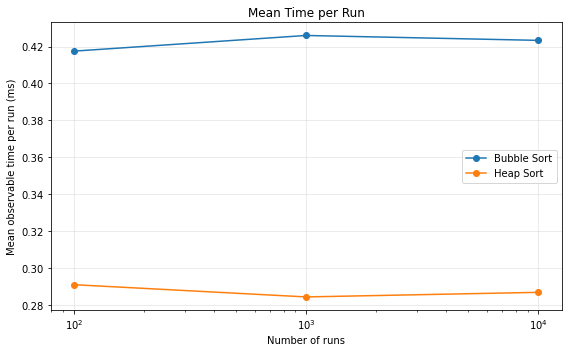

Saved: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures/mean_time_per_run.png


In [21]:
# ============================================================
# 图1：平均运行时间对比
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["rounds"],
    comparison_df["bubble_mean_ms"],
    marker="o",
    label="Bubble Sort",
)

plt.plot(
    comparison_df["rounds"],
    comparison_df["heap_mean_ms"],
    marker="o",
    label="Heap Sort",
)

plt.xscale("log")
plt.xlabel("Number of runs")
plt.ylabel("Mean observable time per run (ms)")
plt.title("Mean Time per Run")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

mean_time_path = FIGURE_DIR / "mean_time_per_run.png"
plt.savefig(mean_time_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {mean_time_path.resolve()}")

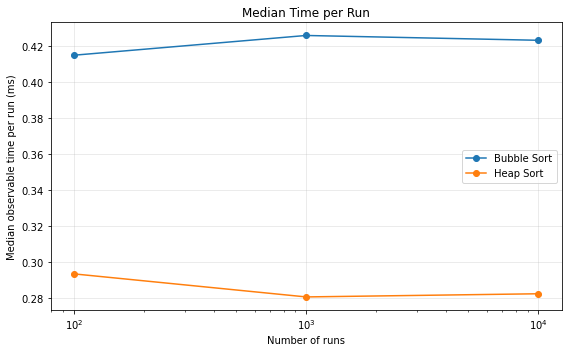

Saved: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures/median_time_per_run.png


In [22]:
# ============================================================
# 图2：中位数运行时间对比
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["rounds"],
    comparison_df["bubble_median_ms"],
    marker="o",
    label="Bubble Sort",
)

plt.plot(
    comparison_df["rounds"],
    comparison_df["heap_median_ms"],
    marker="o",
    label="Heap Sort",
)

plt.xscale("log")
plt.xlabel("Number of runs")
plt.ylabel("Median observable time per run (ms)")
plt.title("Median Time per Run")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

median_time_path = FIGURE_DIR / "median_time_per_run.png"
plt.savefig(median_time_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {median_time_path.resolve()}")

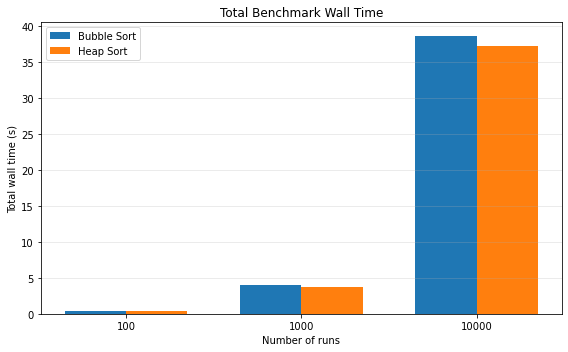

Saved: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures/total_wall_time_bar.png


In [23]:
# ============================================================
# 图3：总运行时间对比（柱状图）
# 这里使用的是每组测试完整墙钟时间 wall time
# ============================================================

x_values = list(range(len(comparison_df)))
x_labels = [str(value) for value in comparison_df["rounds"]]
bar_width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [x - bar_width / 2 for x in x_values],
    comparison_df["bubble_wall_time_s"],
    width=bar_width,
    label="Bubble Sort",
)

plt.bar(
    [x + bar_width / 2 for x in x_values],
    comparison_df["heap_wall_time_s"],
    width=bar_width,
    label="Heap Sort",
)

plt.xticks(x_values, x_labels)
plt.xlabel("Number of runs")
plt.ylabel("Total wall time (s)")
plt.title("Total Benchmark Wall Time")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

total_time_path = FIGURE_DIR / "total_wall_time_bar.png"
plt.savefig(total_time_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {total_time_path.resolve()}")

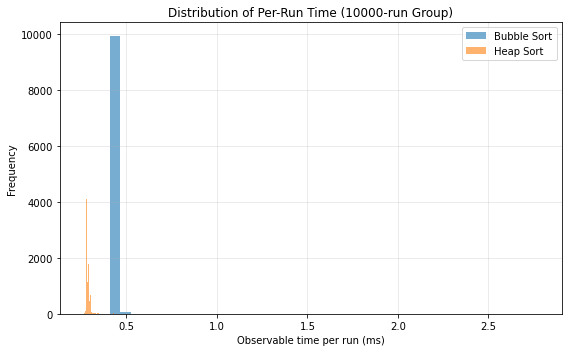

Saved: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures/histogram_10000_runs.png


In [24]:
# ============================================================
# 图5：10000轮测试下，两种算法单轮时间分布直方图
# ============================================================

target_group = 10000

bubble_10000 = raw_results_df[
    (raw_results_df["algorithm"] == "Bubble Sort")
    & (raw_results_df["round_group"] == target_group)
]["elapsed_ms"]

heap_10000 = raw_results_df[
    (raw_results_df["algorithm"] == "Heap Sort")
    & (raw_results_df["round_group"] == target_group)
]["elapsed_ms"]

plt.figure(figsize=(8, 5))

plt.hist(
    bubble_10000,
    bins=40,
    alpha=0.6,
    label="Bubble Sort",
)

plt.hist(
    heap_10000,
    bins=40,
    alpha=0.6,
    label="Heap Sort",
)

plt.xlabel("Observable time per run (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of Per-Run Time (10000-run Group)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

hist_path = FIGURE_DIR / "histogram_10000_runs.png"
plt.savefig(hist_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {hist_path.resolve()}")

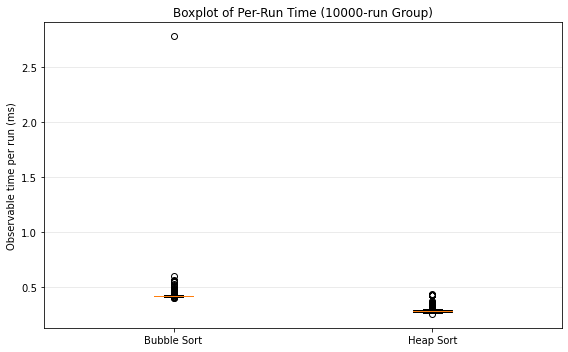

Saved: /home/xilinx/jupyter_notebooks/project_2/benchmark_figures/boxplot_10000_runs.png


In [25]:
# ============================================================
# 图6：10000轮测试下，两种算法单轮时间箱线图
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    [bubble_10000, heap_10000],
    labels=["Bubble Sort", "Heap Sort"],
)

plt.ylabel("Observable time per run (ms)")
plt.title("Boxplot of Per-Run Time (10000-run Group)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

boxplot_path = FIGURE_DIR / "boxplot_10000_runs.png"
plt.savefig(boxplot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {boxplot_path.resolve()}")